# Personal Finance Transaction Analysis and Expense Prediction using Python

The main objective of this project is to analyze financial transaction data,
understand spending patterns, visualize important trends, 
and finally use machine learning to predict the amount of a future transaction.

It follows four major stages: 
  Data Preparation, 
  EDA and Processing, 
  Visualization, 
  Machine Learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
file_path = "dataset/missing_personal.csv"
df = pd.read_csv(file_path)
df.shape

(8080, 15)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             7999 non-null   str    
 1   Description      8080 non-null   str    
 2   Amount           7959 non-null   float64
 3   Category         7917 non-null   str    
 4   PaymentMethod    8080 non-null   str    
 5   Location         8080 non-null   str    
 6   AccountType      8080 non-null   str    
 7   TransactionType  8080 non-null   str    
 8   DeviceUsed       8080 non-null   str    
 9   Currency         8080 non-null   str    
 10  MerchantType     8080 non-null   str    
 11  LoyaltyProgram   8080 non-null   str    
 12  Weekday          8080 non-null   str    
 13  Month            8080 non-null   str    
 14  TimeOfDay        8080 non-null   str    
dtypes: float64(1), str(14)
memory usage: 1.8 MB


Dataset unsing pandas function such as info(), head(), tail(), shape() and describe()

In [4]:
df.head()

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,2025-12-06,Transaction at Myntra,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,2025-06-20,Transaction at BigBazaar,2837.68,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening
3,2025-04-23,Transaction at Property Tax Online,1071.04,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening


In [5]:
df.tail()


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
8075,2025-01-13,Transaction at Vistara,28673.41,Travel,UPI,Kolkata,Credit Card,Debit,Mobile,INR,Service,No,Monday,January,Night
8076,2025-10-25,Transaction at Pepperfry,18983.63,Online Shopping,Net Banking,Delhi,Credit Card,Debit,Mobile,INR,Online Store,Yes,Saturday,October,Night
8077,2025-04-03,Transaction at ACT Fibernet,3226.70,Bills,Net Banking,Kolkata,Credit Card,Debit,Desktop,INR,Service,Yes,Thursday,April,Night
8078,2025-02-03,Transaction at ACT Fibernet,3168.23,Bills,Credit Card,Delhi,Salary,Debit,Mobile,INR,Service,Yes,Monday,February,Morning
8079,2025-05-04,Transaction at Water Board,1304.87,Bills,Credit Card,Delhi,Savings,Debit,Mobile,INR,Service,Yes,Sunday,May,Night


In [6]:
df.describe()

,Amount
count,7959.000000
mean,12504.383026
std,26177.310866
min,54.110000
25%,939.165000
50%,3311.490000
75%,11123.500000
max,149925.200000


In [7]:
df.isnull().sum()

Date                81
Description          0
Amount             121
Category           163
PaymentMethod        0
Location             0
AccountType          0
TransactionType      0
DeviceUsed           0
Currency             0
MerchantType         0
LoyaltyProgram       0
Weekday              0
Month                0
TimeOfDay            0
dtype: int64

In [8]:
missing_per = df.isnull().sum() / len(df) * 100
missing_per.sort_values(ascending=False)

Category           2.017327
Amount             1.497525
Date               1.002475
Description        0.000000
PaymentMethod      0.000000
Location           0.000000
AccountType        0.000000
TransactionType    0.000000
DeviceUsed         0.000000
Currency           0.000000
MerchantType       0.000000
LoyaltyProgram     0.000000
Weekday            0.000000
Month              0.000000
TimeOfDay          0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(80)

In [10]:
df1 = df.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

coerce- convert invalid values into a missing value instead of giving an error.
fillna - replace missing values with another value.

In [11]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df = df.dropna(subset=["Amount"])

mode for categorical columns to fill missing value.
median for amount column as transaction amounts can contain large values and median is less affected.

In [12]:
categorical_columns = [
    "Description",
    "Category",
    "PaymentMethod",
    "Location",
    "AccountType",
    "TransactionType",
    "DeviceUsed",
    "Currency",
    "MerchantType",
    "LoyaltyProgram",
    "Weekday",
    "Month",
    "TimeOfDay"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0]) 

In [13]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())


converted the data colunm into datetime format & extracted month no./day and day no.

In [14]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [15]:
df["Month_Number"] = df["Date"].dt.month


In [16]:
df["Day"] = df["Date"].dt.day


In [17]:
df["Day_Number"] = df["Date"].dt.dayofweek

# EDA & Processing

In [18]:
print("Amount Sum: ",df["Amount"].sum())
print("Amount Mean: ",df["Amount"].mean())
print("Amount Maximun: ",df["Amount"].max())
print("Amount Minimum: ",df["Amount"].min())

Amount Sum:  99522384.5
Amount Mean:  12504.383025505716
Amount Maximun:  149925.2
Amount Minimum:  54.11


In [19]:
category_spending = df.groupby("Category")["Amount"].sum()
category_spending.sort_values(ascending=False)

Category
Electronics        60062434.86
Travel             11837124.25
Online Shopping     9781245.42
Healthcare          8455030.65
Clothing            3185560.90
Bills               2303121.80
Grocery             2009576.00
Transport            806431.08
Food                 633062.52
Entertainment        448797.02
Name: Amount, dtype: float64

In [20]:
# 1. Filter Electronics transactions
electronics_df = df[df["Category"] == "Electronics"]

print("Electronics Transactions:")
display(electronics_df.head())

Electronics Transactions:


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Month_Number,Day,Day_Number
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening,3.0,6.0,3.0
25,2025-05-29,Transaction at Apple Store,131786.69,Electronics,Net Banking,Pune,Current,Debit,Mobile,INR,Retail,No,Thursday,May,Evening,5.0,29.0,3.0
31,2025-05-20,Transaction at Boat Lifestyle,128424.24,Electronics,Debit Card,Chennai,Savings,Debit,POS Terminal,INR,Retail,No,Tuesday,May,Evening,5.0,20.0,1.0
33,2025-09-23,Transaction at OnePlus,134214.53,Electronics,UPI,Pune,Credit Card,Debit,Desktop,INR,Retail,No,Tuesday,September,Morning,9.0,23.0,1.0
40,2025-04-10,Transaction at Apple Store,111005.98,Electronics,UPI,Delhi,Credit Card,Debit,Desktop,INR,Retail,Yes,Thursday,April,Morning,4.0,10.0,3.0


In [52]:
# 2. Transactions greater than ₹10,000
high_value = df[df["Amount"] > 10000]

display(high_value.head())

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Month_Number,Day,Day_Number,High_Expense
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night,4.0,5.0,5.0,True
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening,3.0,6.0,3.0,True
13,2025-05-10,Transaction at IndiGo,24147.34,Travel,Net Banking,Hyderabad,Current,Debit,Mobile,INR,Service,No,Saturday,May,Evening,5.0,10.0,5.0,True
17,2025-05-03,Transaction at IRCTC,11324.06,Travel,Credit Card,Delhi,Credit Card,Debit,Desktop,INR,Service,Yes,Saturday,May,Evening,5.0,3.0,5.0,True
20,2025-11-10,Transaction at Nykaa,16470.71,Online Shopping,UPI,Bangalore,Savings,Debit,POS Terminal,INR,Online Store,No,Monday,November,Morning,11.0,10.0,0.0,True


In [53]:
# 3. UPI transactions
upi_transactions = df[df["PaymentMethod"] == "UPI"]

display(upi_transactions.head())

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Month_Number,Day,Day_Number,High_Expense
7,2025-01-03,Transaction at Airtel,1472.58,Bills,UPI,Mumbai,Salary,Debit,Desktop,INR,Service,Yes,Friday,January,Morning,1.0,3.0,4.0,False
12,2025-06-24,Transaction at Cream Stone,393.35,Food,UPI,Kolkata,Salary,Debit,Desktop,INR,Restaurant,No,Tuesday,June,Afternoon,6.0,24.0,1.0,False
14,2025-07-28,Transaction at Nilgiris,1295.25,Grocery,UPI,Mumbai,Savings,Debit,POS Terminal,INR,Retail,No,Monday,July,Morning,7.0,28.0,0.0,False
15,2025-04-26,Transaction at TSRTC,1287.28,Transport,UPI,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Saturday,April,Evening,4.0,26.0,5.0,False
20,2025-11-10,Transaction at Nykaa,16470.71,Online Shopping,UPI,Bangalore,Savings,Debit,POS Terminal,INR,Online Store,No,Monday,November,Morning,11.0,10.0,0.0,True


In [54]:
# 4. Debit transactions
debit_transactions = df[df["TransactionType"] == "Debit"]

display(debit_transactions.head())

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Month_Number,Day,Day_Number,High_Expense
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night,4.0,5.0,5.0,True
1,2025-12-06,Transaction at Myntra,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening,12.0,6.0,5.0,False
2,2025-06-20,Transaction at BigBazaar,2837.68,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening,6.0,20.0,4.0,False
3,2025-04-23,Transaction at Property Tax Online,1071.04,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon,4.0,23.0,2.0,False
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening,3.0,6.0,3.0,True


In [55]:
# 5. Multiple conditions
high_electronics = df[
    (df["Category"] == "Electronics") &
    (df["Amount"] > 10000)
]

display(high_electronics.head())

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay,Month_Number,Day,Day_Number,High_Expense
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening,3.0,6.0,3.0,True
25,2025-05-29,Transaction at Apple Store,131786.69,Electronics,Net Banking,Pune,Current,Debit,Mobile,INR,Retail,No,Thursday,May,Evening,5.0,29.0,3.0,True
31,2025-05-20,Transaction at Boat Lifestyle,128424.24,Electronics,Debit Card,Chennai,Savings,Debit,POS Terminal,INR,Retail,No,Tuesday,May,Evening,5.0,20.0,1.0,True
33,2025-09-23,Transaction at OnePlus,134214.53,Electronics,UPI,Pune,Credit Card,Debit,Desktop,INR,Retail,No,Tuesday,September,Morning,9.0,23.0,1.0,True
40,2025-04-10,Transaction at Apple Store,111005.98,Electronics,UPI,Delhi,Credit Card,Debit,Desktop,INR,Retail,Yes,Thursday,April,Morning,4.0,10.0,3.0,True


In [21]:
df.groupby("Category")["Amount"].mean()

Category
Bills               3030.423421
Clothing            4213.704894
Electronics        77901.990739
Entertainment        556.820124
Food                 795.304673
Grocery             2593.001290
Healthcare         10729.734327
Online Shopping    10042.346427
Transport           1050.040469
Travel             15473.365033
Name: Amount, dtype: float64

In [22]:
df.groupby("Category").size()

Category
Bills              760
Clothing           756
Electronics        771
Entertainment      806
Food               796
Grocery            775
Healthcare         788
Online Shopping    974
Transport          768
Travel             765
dtype: int64

In [23]:
df.groupby("PaymentMethod")["Amount"].sum()

PaymentMethod
Credit Card    24647819.96
Debit Card     23557489.37
Net Banking    25309220.06
UPI            26007855.11
Name: Amount, dtype: float64

In [24]:
#monthly spending analysis
df.groupby("Month")["Amount"].sum().sort_values(ascending=True)

Month
October      6911127.54
February     7212620.54
April        7859111.20
November     8011357.82
January      8104023.22
December     8516017.21
September    8625744.24
June         8678433.20
August       8683152.19
May          8829809.19
July         8918156.58
March        9172831.57
Name: Amount, dtype: float64

In [25]:
#which location has highest spending
df.groupby("Location")["Amount"].sum().sort_values(ascending=False)

Location
Pune         16183617.96
Hyderabad    16083327.22
Chennai      14077818.49
Mumbai       14064566.24
Bangalore    13203830.47
Delhi        13117262.11
Kolkata      12791962.01
Name: Amount, dtype: float64

In [26]:
#merchant analysis
df.groupby("MerchantType")["Amount"].sum().sort_values(ascending=False)

MerchantType
Retail          66428646.37
Service         23945169.22
Online Store     8046217.60
Restaurant        643419.42
Subscription      458931.89
Name: Amount, dtype: float64

In [27]:
#At what time does the user spend the most money
df.groupby("TimeOfDay")["Amount"].sum()

TimeOfDay
Afternoon    24989185.26
Evening      25007847.89
Morning      27192143.69
Night        22333207.66
Name: Amount, dtype: float64

eval - evaluates a string as a Python expression and returns its result.

inplace - make the change directly to the original DataFrame instead of creating a new one.

In [28]:
high_expenses = df.query("Amount > 5000")
df.eval("High_Expense = Amount > 5000", inplace=True)  
df.groupby(["Category", "PaymentMethod"])["Amount"].sum()                             
                              

Category         PaymentMethod
Bills            Credit Card        596798.64
                 Debit Card         588471.44
                 Net Banking        557583.25
                 UPI                560268.47
Clothing         Credit Card        773189.51
                 Debit Card         842687.54
                 Net Banking        777107.84
                 UPI                792576.01
Electronics      Credit Card      14780081.26
                 Debit Card       14033257.86
                 Net Banking      15124930.11
                 UPI              16124165.63
Entertainment    Credit Card        114764.23
                 Debit Card          98124.79
                 Net Banking        119982.38
                 UPI                115925.62
Food             Credit Card        172322.26
                 Debit Card         168257.96
                 Net Banking        137163.63
                 UPI                155318.67
Grocery          Credit Card        545335.81
   

# Visualization 


after performing the analysis, results converted into visualization.

In [29]:
pivot = pd.pivot_table(
    df,
    values="Amount",
    index="Category",
    columns="PaymentMethod",
    aggfunc="sum"
)

pivot

PaymentMethod,Credit Card,Debit Card,Net Banking,UPI
Category,,,,
Bills,596798.64,588471.44,557583.25,560268.47
Clothing,773189.51,842687.54,777107.84,792576.01
Electronics,14780081.26,14033257.86,15124930.11,16124165.63
Entertainment,114764.23,98124.79,119982.38,115925.62
Food,172322.26,168257.96,137163.63,155318.67
Grocery,545335.81,456180.31,513853.56,494206.32
Healthcare,2069802.98,2034141.71,2242329.39,2108756.57
Online Shopping,2330862.30,2430889.53,2572364.48,2447129.11
Transport,209820.27,208768.50,189852.79,197989.52


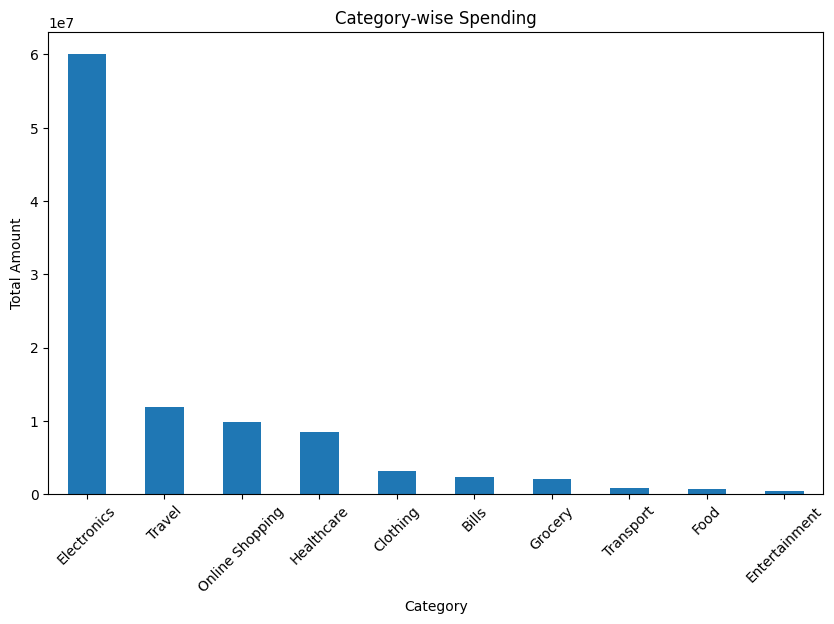

In [30]:
# Bar graph: Category Spending used to compare categorical values
category_spending = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

category_spending.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Category-wise Spending")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

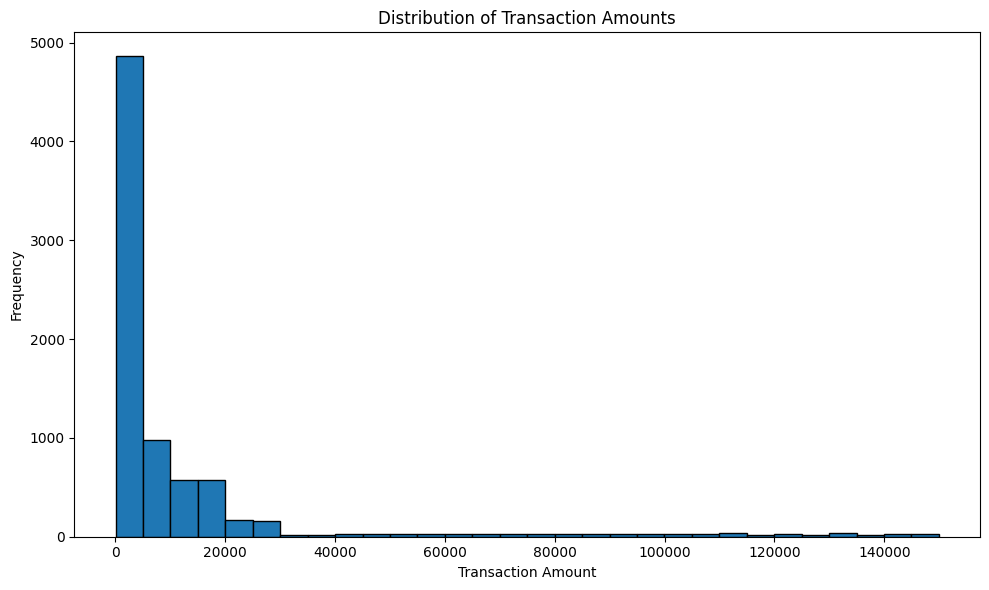

In [31]:
# Histrograph: Spending Distribution shows the distribution of a continuous numercial value
plt.figure(figsize=(10, 6))

plt.hist(
    df["Amount"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

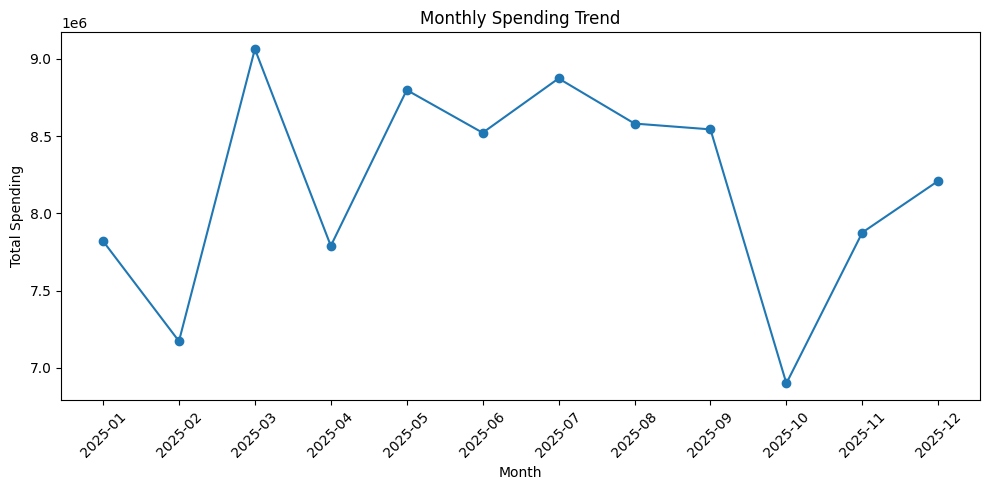

In [32]:
#Line graph: payment method
df["Date"] = pd.to_datetime(df["Date"])

monthly_spending = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum()
monthly_spending.index = monthly_spending.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_spending.index,
    monthly_spending.values,
    marker="o"
)
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

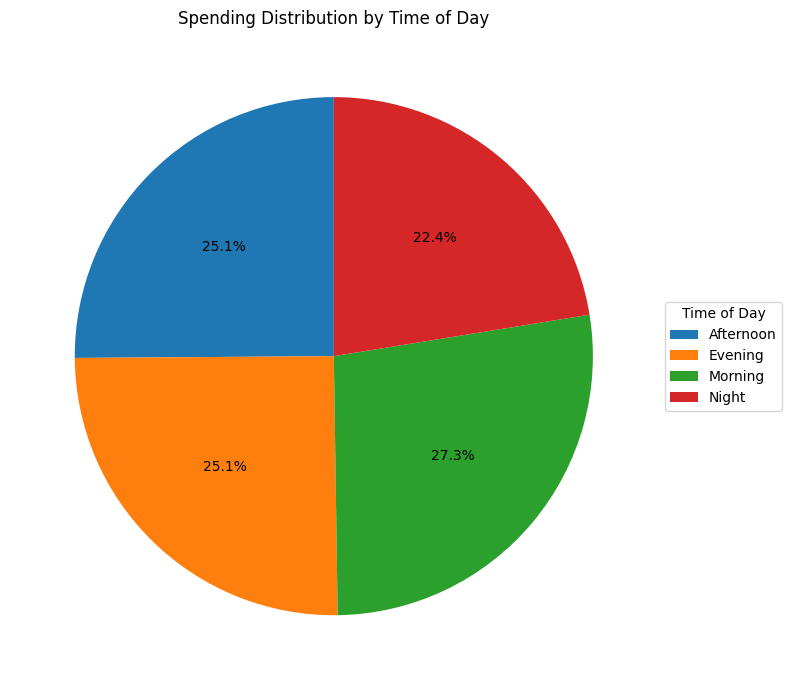

In [33]:
#Pie Chart: Spending by Time of Day

time_spending = df.groupby("TimeOfDay")["Amount"].sum()

plt.figure(figsize=(9, 7))

plt.pie(
    time_spending,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Spending Distribution by Time of Day")

plt.legend(
    time_spending.index,
    title="Time of Day",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

Correlation Analysis measures the strength & direction of a relationship between numerical variables
 

-1 (strong negative relationship)
  0  (no linear relationship)
 +1 (strong positive relationship)

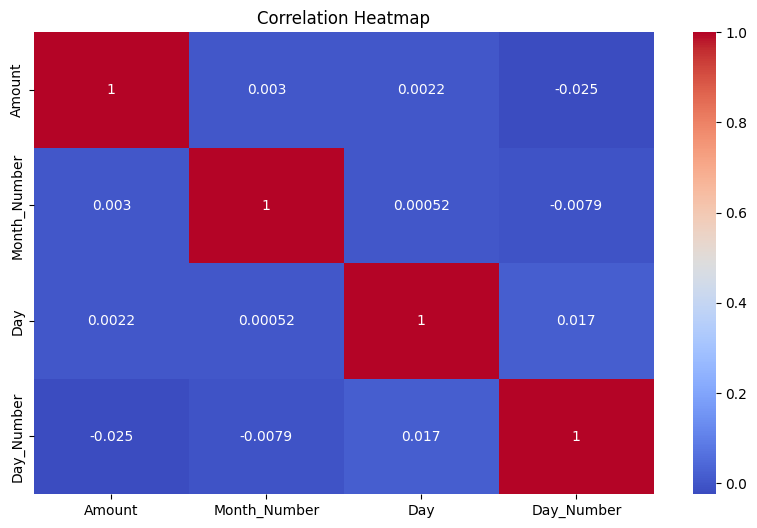

In [34]:
#correlation heatmap for numerical variables
numeric_df = df.select_dtypes(
    include=np.number
)
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
#Interactive Plotly Visualization - create an interactive category-wise spending visualization.
fig = px.bar(
    df.groupby("Category", as_index=False)["Amount"].sum(),
    x="Category",
    y="Amount",
    title="Interactive Category-wise Spending"
)

fig.show()

# Machine learning
Predict the amount of a future transaction based on its characteristics.

characteristics - input variable(X)
Amount - target variable(y)

In [36]:
X = df[
    [
        "Category",
        "PaymentMethod",
        "Location",
        "AccountType",
        "TransactionType",
        "DeviceUsed",
        "MerchantType",
        "LoyaltyProgram",
        "TimeOfDay",
        "Month_Number",
        "Day_Number"
    ]
]

y = df["Amount"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [38]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

print("\nData types:")
print(X.dtypes)

Missing values in X:
Category            0
PaymentMethod       0
Location            0
AccountType         0
TransactionType     0
DeviceUsed          0
MerchantType        0
LoyaltyProgram      0
TimeOfDay           0
Month_Number       79
Day_Number         79
dtype: int64

Missing values in y:
0

Data types:
Category               str
PaymentMethod          str
Location               str
AccountType            str
TransactionType        str
DeviceUsed             str
MerchantType           str
LoyaltyProgram         str
TimeOfDay              str
Month_Number       float64
Day_Number         float64
dtype: object


In [39]:
print("Missing y_train:", y_train.isnull().sum())
print("Missing y_test:", y_test.isnull().sum())

Missing y_train: 0
Missing y_test: 0


In [40]:
print(df["Amount"].isnull().sum())

0


In [41]:
categorical_features = X.select_dtypes(
    include="object"
).columns

numeric_features = X.select_dtypes(
    include=np.number
).columns

C:\Users\kvbak\AppData\Local\Temp\ipykernel_28048\3753905510.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Encode Categorical Data - use OneHotEncoder rather than manually encoding every category 
here machine learning models require numerical input, and onehot encoding converts categorical variables into numerical binary features without imposing an artifical order

StandardScaler - To standardize numerical features so that they are on a comparable scale

simpleimputer - it is a Scikit-learn tool used to fill missing values in data before giving the data to a ML model.

Pipeline allows you to sequentially apply a list of transformers to preprocess the data and if desired conclude the sequence with a final predictor for predictive modeling.


In [42]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [43]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numerical", numeric_pipeline, numeric_features)
    ]
)

Regression method is used to predict a continuous numerical value and in my project my target variable is AMOUNT which is continuous numerical value 
 
here i tested two regression models: linear regression and random forest regression 
and regression contain evaluation metrics: MAE, RMSE, R^2


linear regression - used as a simple baseline to see whether transaction features have a relatively linear relation with amount

random forest regression - used to capture more complex, non-linear relationship between features such as category, payment method, location and time

In [45]:
#Linear Regression 
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [46]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Category','PaymentMethod','Location',...,'TimeOfDay','Month_Number', 'Day_Number']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thro

In [47]:
linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression model trained successfully!")
print("Number of predictions:", len(linear_predictions))

Linear Regression model trained successfully!
Number of predictions: 1592


In [48]:
#random forest regression
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

evaluation metrics contain major methods like MAE, RMSE, R^2

mean absolute error - measures the average absolute diff bet. predicted & actual values
root mean squared error - measures prediction error whike giving more weight to larger errors
R^2 - measures how much of the variation in the target variable is explained by the model. it is not classification accuracy. it measures explained variance for regression.

modal comparison - two diiferent approaches and select the better performing model using MAE, RMSE, R^2

model performance depends on the characteristics of the dataset & features in this particular test split, LR produced lower MAE & RMSE and higher R^2 so it performed better

In [49]:
#model comparison
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,6276.065197,14065.289876,0.736785
1,Random Forest,6309.872722,14841.393166,0.706936


# Model to predict a new transaction amount

In [50]:
#predict a new transaction
new_transaction = pd.DataFrame({
    "Category": ["Food"],
    "PaymentMethod": ["UPI"],
    "Location": ["Mumbai"],
    "AccountType": ["Savings"],
    "TransactionType": ["Expense"],
    "DeviceUsed": ["Mobile"],
    "MerchantType": ["Restaurant"],
    "LoyaltyProgram": ["Yes"],
    "TimeOfDay": ["Evening"],
    "Month_Number": [8],
    "Day_Number": [2]
})

In [51]:
prediction = rf_model.predict(new_transaction)

print(
    "Predicted Expense Amount:",
    prediction[0]
)

Predicted Expense Amount: 846.9697999999999


the project starts with data preparation, continues with EDA and processing, uses visualization to communicate patterns, and finally applies machine learning for transaction amount prediction

the major insight from my analysis is that electronics represents the largest spending category, while UPI is the highest-value payment method and morning has the highest total spending by time of day.